In [1]:
# ==================================================
# SECTION 1: IMPORT LIBRARIES
# ==================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

pd.set_option('display.max_columns', None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [7]:
import os

print(os.getcwd())

d:\F C U L univeristy\University\Level 3\Second Term\Projects Decodelap\Data Science Project 1\notebooks


In [8]:
import os

print(os.listdir("../data/raw"))

['Dataset for Data Analytics.xlsx']


In [10]:
# ==================================================
# SECTION 2: LOAD DATASET
# ==================================================

df = pd.read_excel("../data/raw/Dataset for Data Analytics.xlsx")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [11]:
# ==================================================
# SECTION 3: BASIC EXPLORATION
# ==================================================

print("First 5 Rows")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Info")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
display(df.isnull().sum())

First 5 Rows


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



Dataset Shape
(1200, 14)

Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtype

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558



Missing Values


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [12]:
# ==================================================
# SECTION 4: CHECK DUPLICATES
# ==================================================

duplicates = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicates)

Number of Duplicate Rows: 0


In [13]:
# ==================================================
# SECTION 5: HANDLE MISSING VALUES
# ==================================================

print("Missing Values Before Cleaning")
display(df.isnull().sum())

Missing Values Before Cleaning


OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [14]:
# CouponCode contains missing values

df["CouponCode"] = df["CouponCode"].fillna("No Coupon")

In [15]:
print("Missing Values After Cleaning")
display(df.isnull().sum())

Missing Values After Cleaning


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [16]:
# ==================================================
# SECTION 6: OUTLIER DETECTION USING IQR
# ==================================================

numeric_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column} -> {len(outliers)} Outliers")

Quantity -> 0 Outliers
UnitPrice -> 0 Outliers
ItemsInCart -> 0 Outliers
TotalPrice -> 8 Outliers


In [17]:
# ==================================================
# SECTION 7: REMOVE OUTLIERS
# ==================================================

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - (1.5 * IQR)

    upper = Q3 + (1.5 * IQR)

    df = df[
        (df[column] >= lower) &
        (df[column] <= upper)
    ]

print("Shape After Removing Outliers")
print(df.shape)

Shape After Removing Outliers
(1192, 14)


In [18]:
# ==================================================
# SECTION 8: FEATURE ENGINEERING
# ==================================================

df["Date"] = pd.to_datetime(df["Date"])

In [19]:
# Feature 1

df["Month"] = df["Date"].dt.month

In [20]:
# Feature 2

df["Year"] = df["Date"].dt.year

In [21]:
# Feature 3

df["Day"] = df["Date"].dt.day

In [22]:
# Feature 4

df["PricePerItem"] = (
    df["TotalPrice"] /
    df["Quantity"]
)

In [23]:
# Feature 5

df["UsedCoupon"] = (
    df["CouponCode"] != "No Coupon"
).astype(int)

In [24]:
# Feature 6

df["CartValue"] = (
    df["TotalPrice"] /
    df["ItemsInCart"]
)

In [25]:
print("New Features Added Successfully")
display(df.head())

New Features Added Successfully


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year,Day,PricePerItem,UsedCoupon,CartValue
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023,4,570.62,1,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024,23,151.35,1,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024,27,550.68,1,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023,15,273.19,1,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025,8,626.01,1,313.005000


In [26]:
# ==================================================
# SECTION 9: EDA VISUALIZATIONS
# ==================================================

sns.set_style("whitegrid")

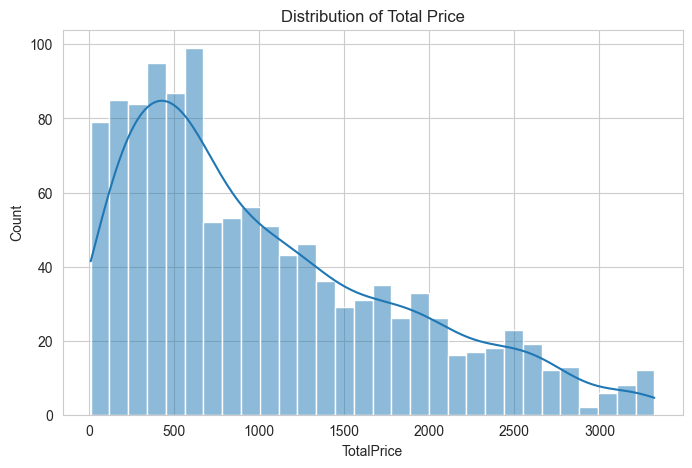

In [27]:
# Distribution of Total Price

plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalPrice"],
    bins=30,
    kde=True
)

plt.title("Distribution of Total Price")

plt.show()

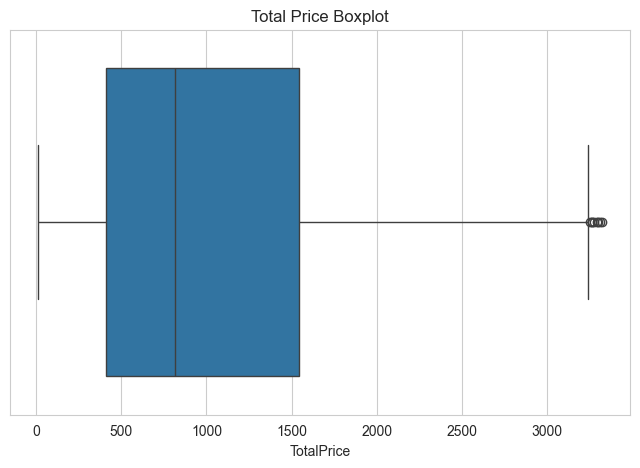

In [28]:
# Boxplot

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["TotalPrice"]
)

plt.title("Total Price Boxplot")

plt.show()

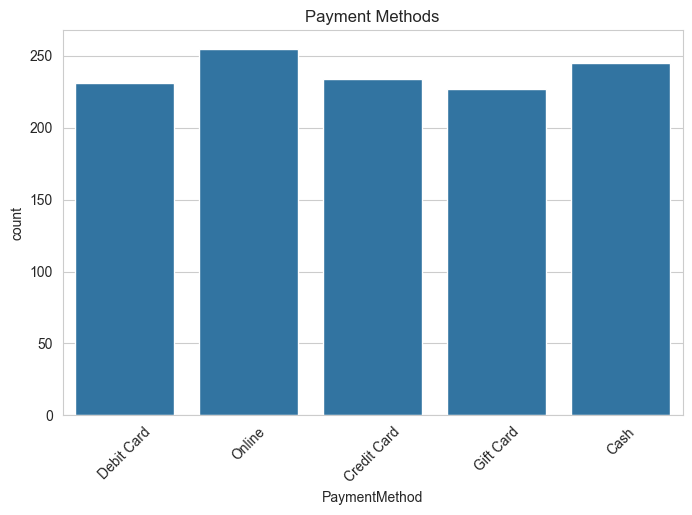

In [29]:
# Payment Methods

plt.figure(figsize=(8,5))

sns.countplot(
    x="PaymentMethod",
    data=df
)

plt.xticks(rotation=45)

plt.title("Payment Methods")

plt.show()

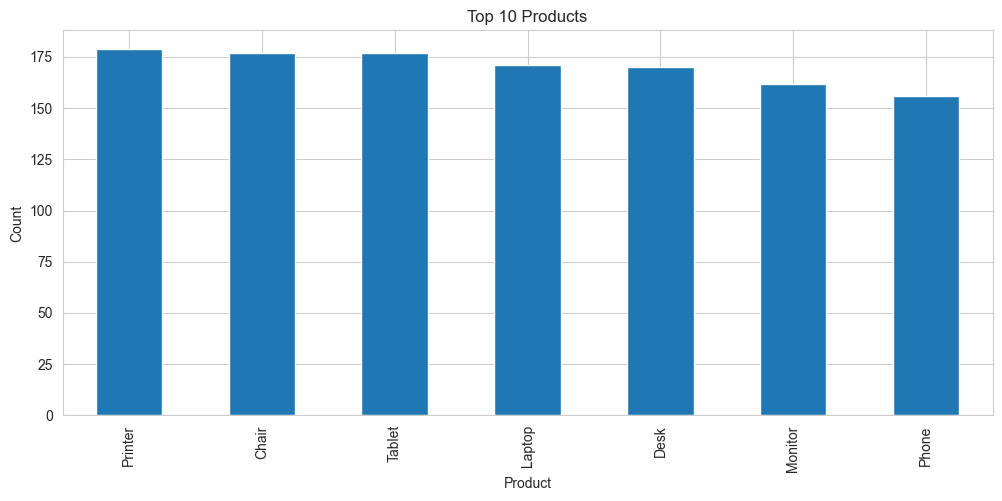

In [32]:
plt.figure(figsize=(12,5))

df["Product"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Products")

plt.xlabel("Product")

plt.ylabel("Count")

plt.show()

In [31]:
print(df.columns.tolist())

['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Month', 'Year', 'Day', 'PricePerItem', 'UsedCoupon', 'CartValue']


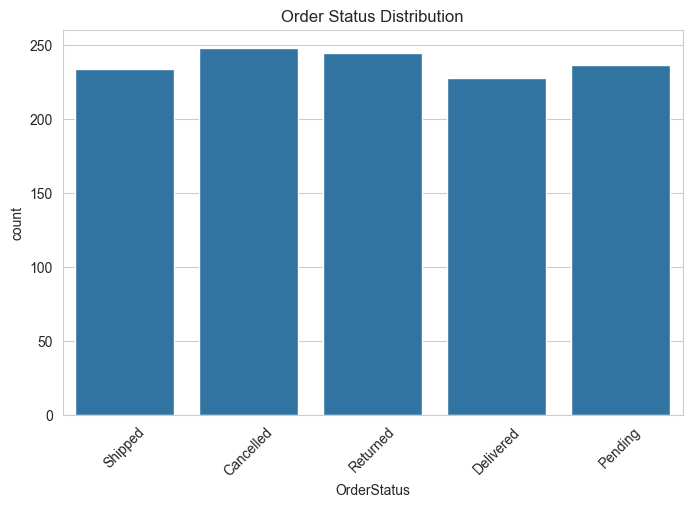

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="OrderStatus",
    data=df
)

plt.title("Order Status Distribution")

plt.xticks(rotation=45)

plt.show()

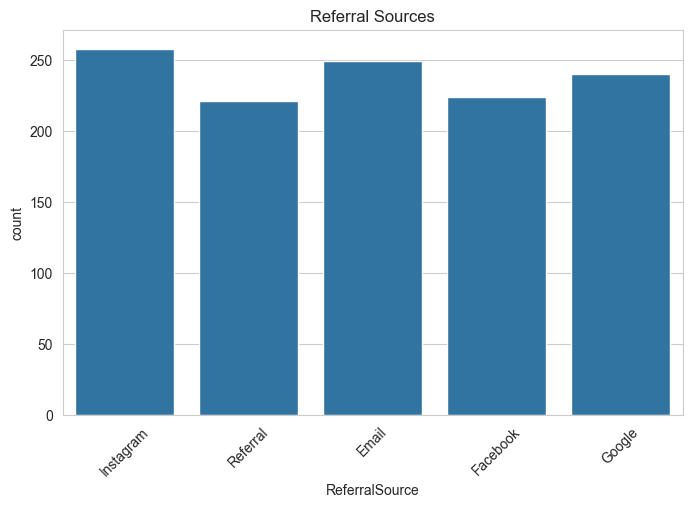

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="ReferralSource",
    data=df
)

plt.title("Referral Sources")

plt.xticks(rotation=45)

plt.show()

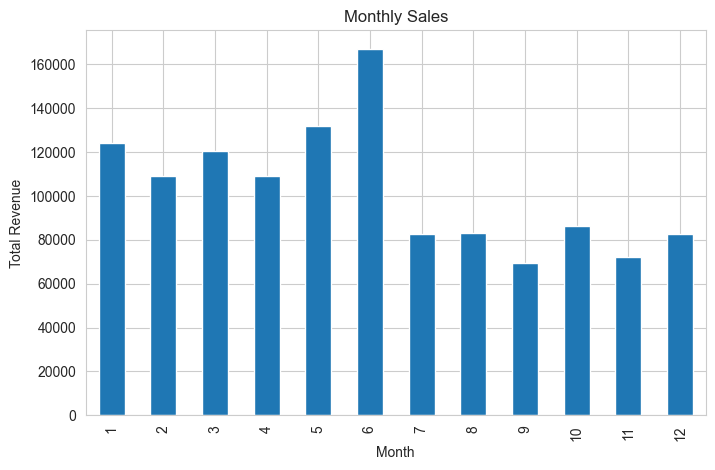

In [35]:
monthly_sales = df.groupby("Month")["TotalPrice"].sum()

plt.figure(figsize=(8,5))

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales")

plt.ylabel("Total Revenue")

plt.show()

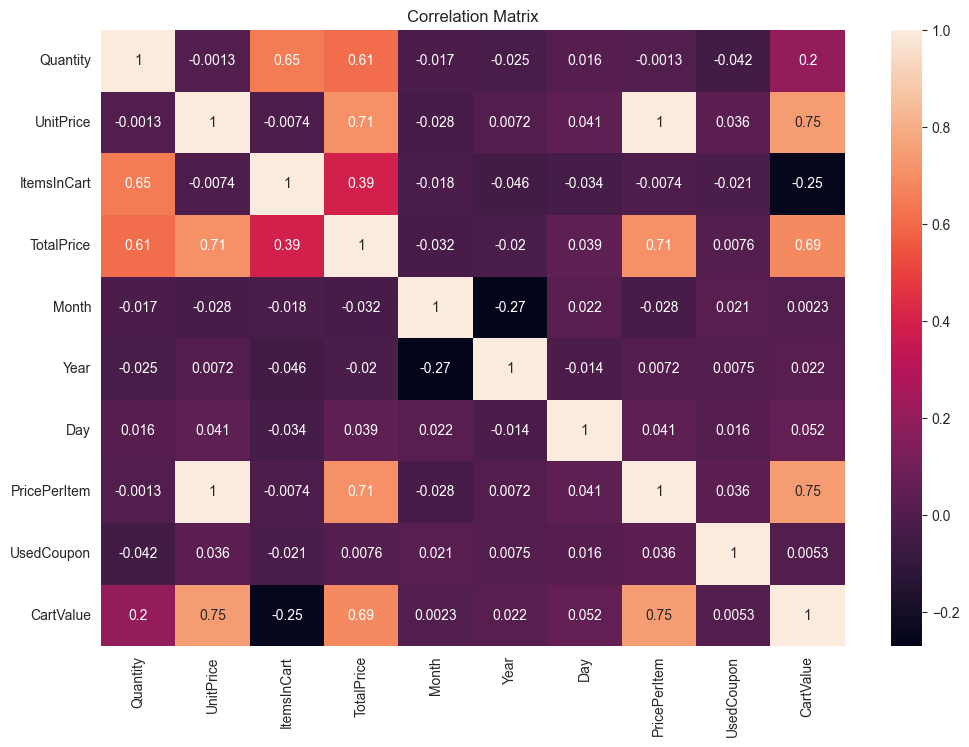

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True
)

plt.title("Correlation Matrix")

plt.show()

In [37]:
# ==================================================
# SECTION 10: FINAL DATASET CHECK
# ==================================================

print("Final Shape")
print(df.shape)

print("\nMissing Values")
display(df.isnull().sum())

display(df.head())

Final Shape
(1192, 20)

Missing Values


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
Month              0
Year               0
Day                0
PricePerItem       0
UsedCoupon         0
CartValue          0
dtype: int64

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Month,Year,Day,PricePerItem,UsedCoupon,CartValue
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,2023,4,570.62,1,407.585714
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,2024,23,151.35,1,100.900000
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,2024,27,550.68,1,344.175000
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,2023,15,273.19,1,54.638000
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,2025,8,626.01,1,313.005000


In [39]:
# ==================================================
# SECTION 11: SAVE CLEAN DATASET
# ==================================================

df.to_csv(
    "cleaned_dataset.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [40]:
# Excel

df.to_excel(
    "cleaned_dataset.xlsx",
    index=False
)

In [38]:
# ==================================================
# SECTION 12: PROJECT CONCLUSION
# ==================================================

print("""
Project Completed Successfully

Tasks Performed:

1. Data Loading
2. Data Exploration
3. Missing Value Handling
4. Outlier Detection
5. Outlier Removal
6. Feature Engineering
7. Data Visualization
8. Dataset Export
""")


Project Completed Successfully

Tasks Performed:

1. Data Loading
2. Data Exploration
3. Missing Value Handling
4. Outlier Detection
5. Outlier Removal
6. Feature Engineering
7. Data Visualization
8. Dataset Export

